# Preprocessing & Tokenisation

Model: camembert-base

Goal: Tokenize Allociné reviews and prepare DataLoaders for fine-tuning

In [13]:
from datasets import load_dataset
from transformers import CamembertTokenizer
import torch
from torch.utils.data import DataLoader
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import pickle

## 1. Load dataset

Dans cette section, on charge le dataset Allociné depuis HuggingFace. C'est un dataset de critiques de films en français, avec 160 000 exemples d'entraînement, 20 000 de validation et 20 000 de test. Chaque exemple contient une review (texte) et un label (0 = négatif, 1 = positif).

In [3]:
dataset = load_dataset('allocine')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})


## 2. Load CamemBERT tokenizer

On charge le tokenizer de camembert-base. Son rôle est de convertir le texte brut en nombres (tokens) que le modèle peut comprendre. Le vocabulaire contient 32 005 tokens et la longueur maximale acceptée par le modèle est 512 tokens.

In [4]:
MODEL_NAME = 'camembert-base'
tokenizer = CamembertTokenizer.from_pretrained(MODEL_NAME)

print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max length: {tokenizer.model_max_length}')

Vocab size: 32005
Max length: 512


## 3. Analyse token length distribution

Avant de tokeniser tout le dataset, on analyse la distribution des longueurs sur un échantillon de 2 000 reviews. Cela nous permet de choisir un MAX_LENGTH adapté — assez grand pour ne pas perdre d'information, assez petit pour économiser de la mémoire GPU.

count    2000.000000
mean      127.135500
std       102.791012
min         3.000000
25%        47.000000
50%        94.000000
75%       181.000000
max       502.000000
Name: n_tokens, dtype: float64

Reviews > 512 tokens: 0 / 2000


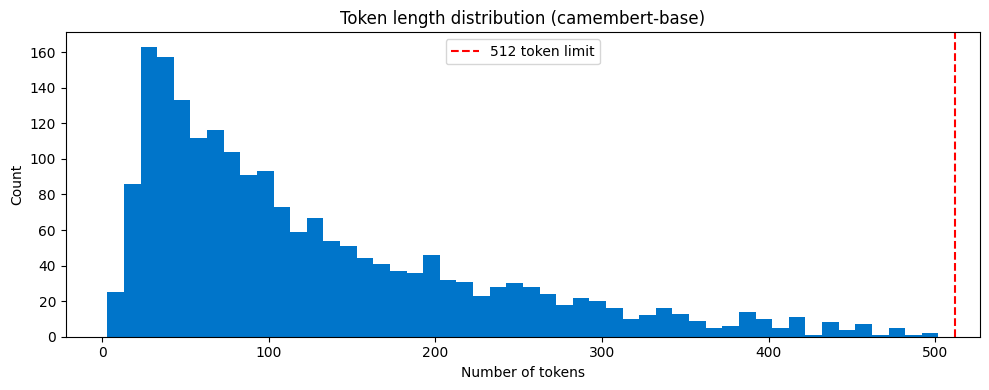

In [5]:
sample = pd.DataFrame(dataset['train']).sample(2000, random_state=42)
sample['n_tokens'] = sample['review'].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(sample['n_tokens'].describe())
print(f"\nReviews > 512 tokens: {(sample['n_tokens'] > 512).sum()} / {len(sample)}")

plt.figure(figsize=(10, 4))
plt.hist(sample['n_tokens'], bins=50, color='#0075ca', edgecolor='none')
plt.axvline(512, color='red', linestyle='--', label='512 token limit')
plt.title('Token length distribution (camembert-base)')
plt.xlabel('Number of tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/token_length.png', dpi=150)
plt.show()

## 4. Tokenize the full dataset

On tokenise les 200 000 reviews avec MAX_LENGTH=256. Chaque review est convertie en input_ids (les tokens) et attention_mask (indique quels tokens sont réels vs padding). On utilise le traitement par
batch pour accélérer l'opération.

In [6]:
MAX_LENGTH = 256  # covers most reviews, reduces memory usage

def tokenize(batch):
    return tokenizer(
        batch['review'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(tokenized)

DatasetDict({
    train: Dataset({
        features: ['review', 'label', 'input_ids', 'attention_mask'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label', 'input_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label', 'input_ids', 'attention_mask'],
        num_rows: 20000
    })
})


## 5. Create train / val / test split

On sépare le dataset tokenisé en trois parties : train pour entraîner le modèle, validation pour surveiller les performances pendant l'entraînement, et test pour l'évaluation finale.

In [9]:
train_dataset = tokenized['train']
val_dataset   = tokenized['validation']
test_dataset  = tokenized['test']

print(f'Train: {len(train_dataset)}')
print(f'Val:   {len(val_dataset)}')
print(f'Test:  {len(test_dataset)}')

Train: 160000
Val:   20000
Test:  20000


## 6. Create DataLoaders

On crée les DataLoaders qui vont alimenter le modèle pendant l'entraînement. Ils découpent les données en batches de 16 reviews, et mélangent aléatoirement les données d'entraînement à chaque epoch
pour éviter que le modèle apprenne l'ordre des exemples.

In [11]:
def collate_fn(batch):
    return {
        'input_ids':      torch.stack([x['input_ids'].clone().detach() for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'].clone().detach() for x in batch]),
        'label':          torch.tensor([x['label'] for x in batch])
    }

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, collate_fn=collate_fn)

batch = next(iter(train_loader))
print('input_ids shape:     ', batch['input_ids'].shape)
print('attention_mask shape:', batch['attention_mask'].shape)
print('labels:              ', batch['label'])

input_ids shape:      torch.Size([16, 256])
attention_mask shape: torch.Size([16, 256])
labels:               tensor([1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0])


## 7. Key observations

- MAX_LENGTH choisi : 256 tokens — couvre la quasi-totalité des reviews
- % reviews tronquées : 0% — aucune review ne dépasse 512 tokens (max observé : 502)
- Train / Val / Test sizes : 160 000 / 20 000 / 20 000
- Batch shape vérifié : torch.Size([16, 256]) — 16 reviews × 256 tokens 

In [14]:
os.makedirs('../results/data', exist_ok=True)

pickle.dump({
    'train': train_dataset,
    'val':   val_dataset,
    'test':  test_dataset
}, open('../results/data/tokenized_datasets.pkl', 'wb'))